In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

raw_path = BASE_DIR / "data" / "raw"
processed_path = BASE_DIR / "data" / "processed"

print(raw_path)
print(processed_path)

c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\raw
c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\processed


In [3]:
performance = pd.read_csv(processed_path/"clean_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


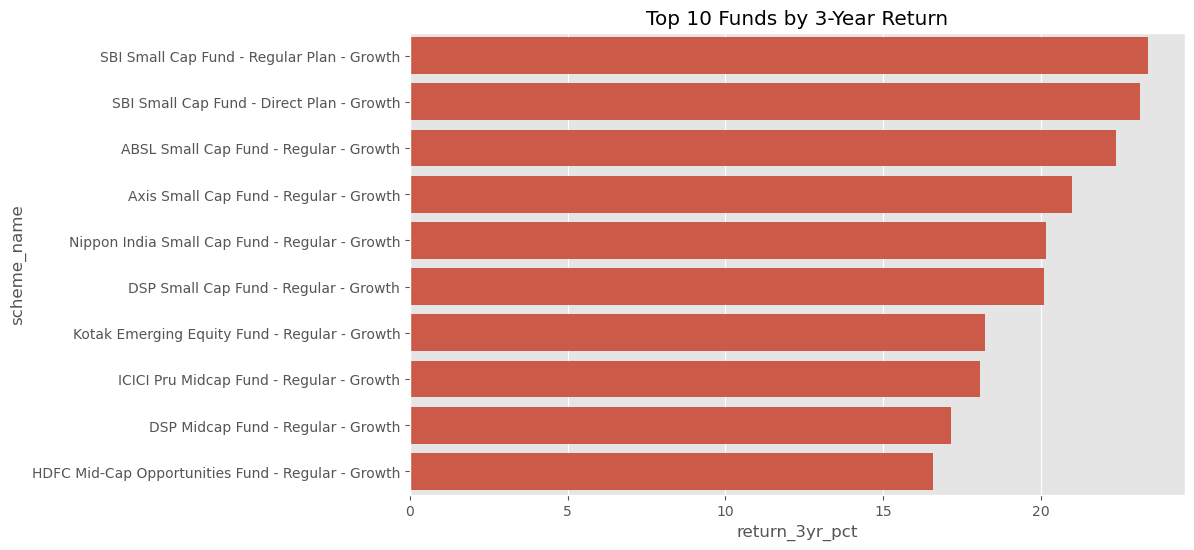

In [9]:
top_returns=performance.sort_values(
    'return_3yr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_returns,
    x='return_3yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 3-Year Return")
plt.show()

Which funds generated the highest long-term returns?

In [11]:
performance['sharpe_ratio'].unique()

array([0.88, 0.81, 0.94, 0.93, 1.52, 1.06, 0.96, 0.87, 0.8 , 1.84, 0.82,
       1.03, 0.95, 0.98, 7.68, 1.  , 0.91, 1.33, 6.18, 0.85, 0.84, 0.9 ,
       5.14, 0.92])

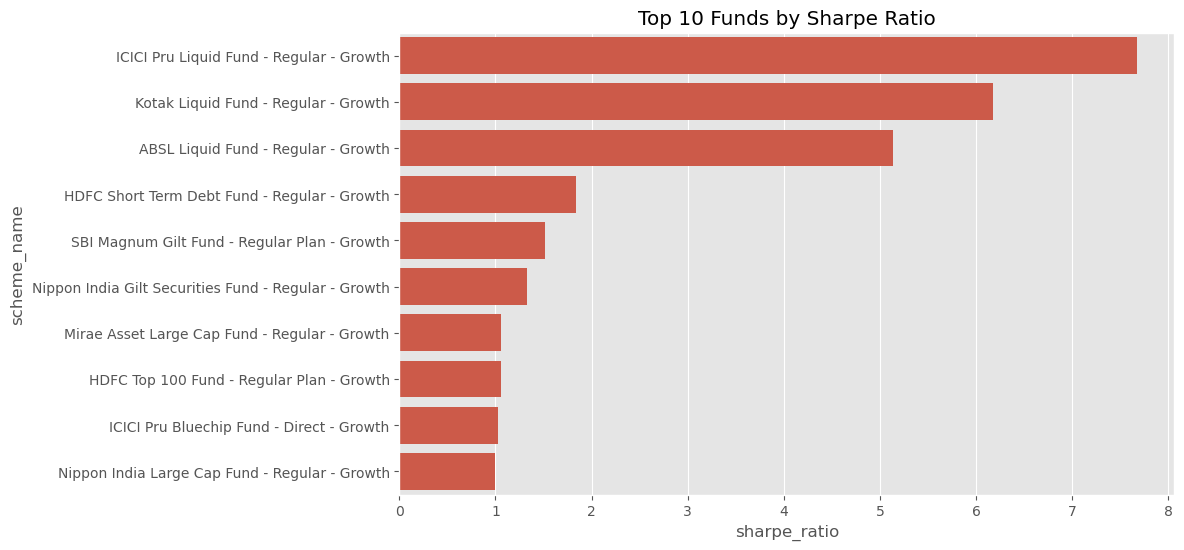

In [16]:
top_sharpe = performance.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()

Higher Sharpe Ratio = Better risk-adjusted return.

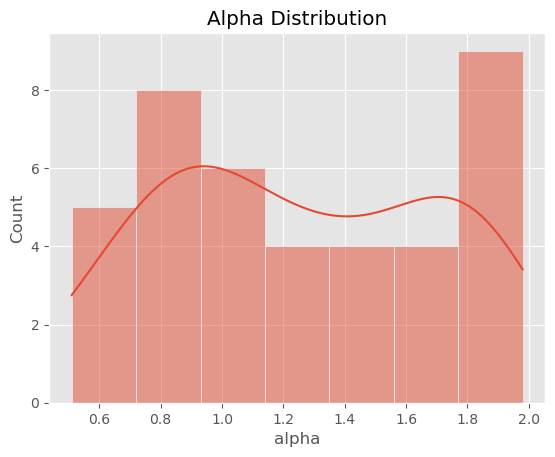

In [20]:
sns.histplot(
    performance['alpha'],
    kde=True
)

plt.title("Alpha Distribution")
plt.show()

Positive alpha means outperforming the benchmark.

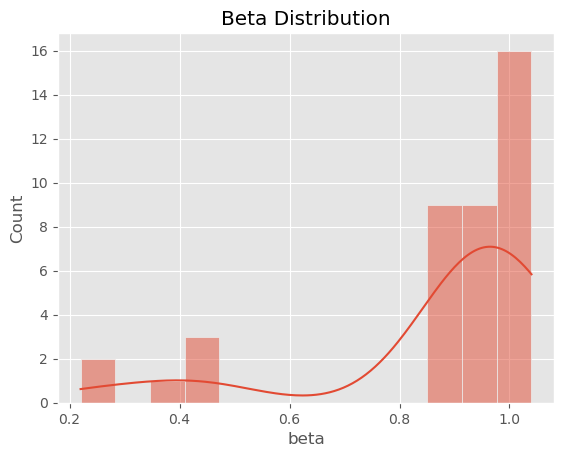

In [21]:
sns.histplot(
    performance['beta'],
    kde=True
)

plt.title("Beta Distribution")
plt.show()

- Beta > 1 → More volatile than market.
- Beta < 1 → Less volatile.

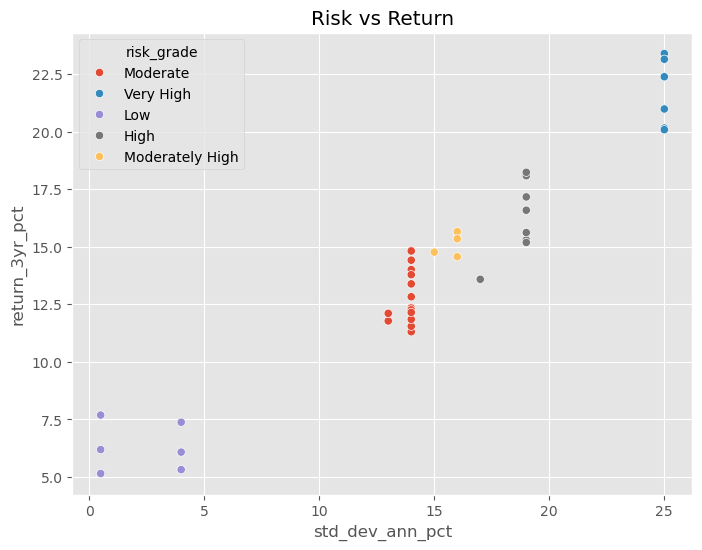

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    hue='risk_grade'
)

plt.title("Risk vs Return")
plt.show()

Do higher-risk funds give higher returns?

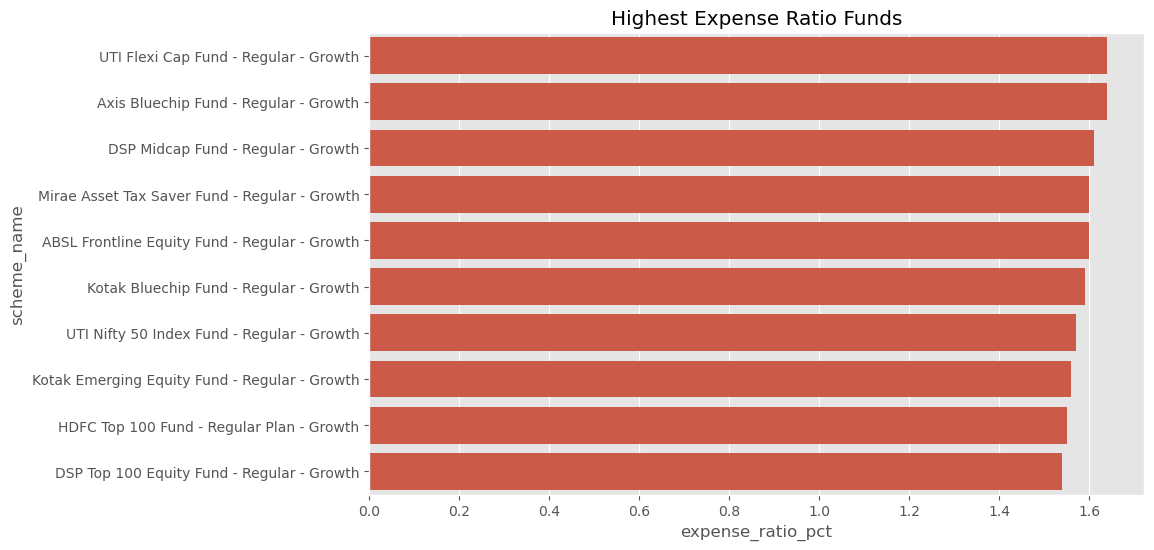

In [23]:
top_expense = performance.sort_values(
    'expense_ratio_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_expense,
    x='expense_ratio_pct',
    y='scheme_name'
)

plt.title("Highest Expense Ratio Funds")
plt.show()

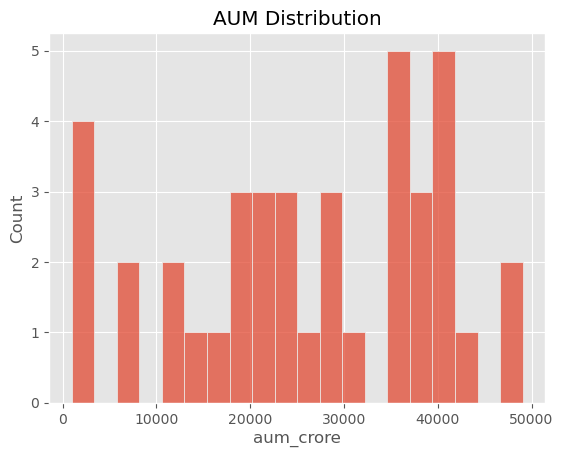

In [24]:
sns.histplot(
    performance['aum_crore'],
    bins=20
)

plt.title("AUM Distribution")
plt.show()

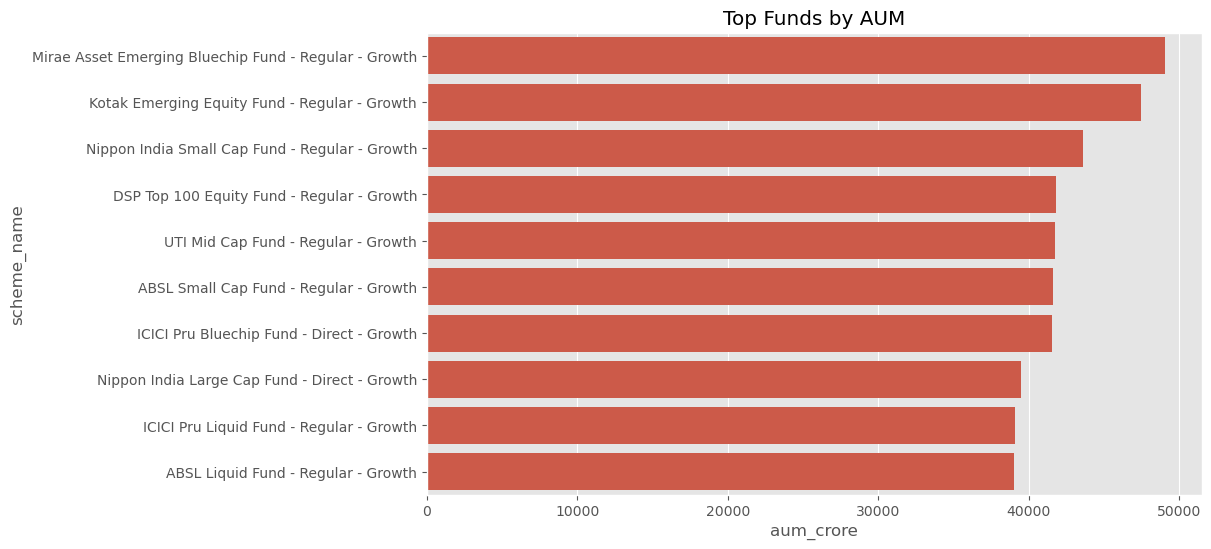

In [25]:
top_aum = performance.sort_values(
    'aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_aum,
    x='aum_crore',
    y='scheme_name'
)

plt.title("Top Funds by AUM")
plt.show()

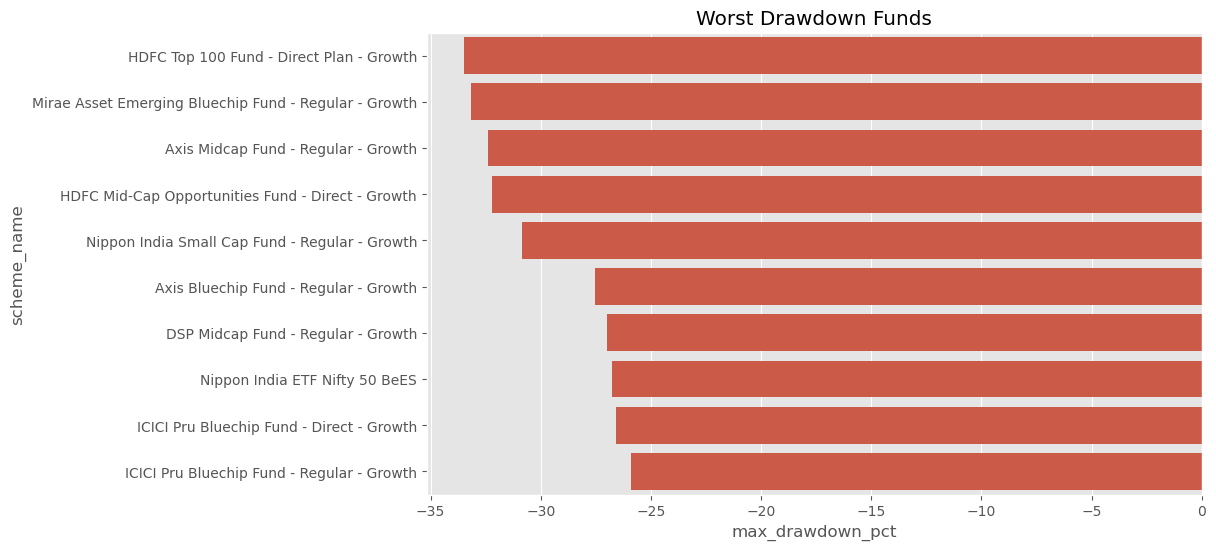

In [26]:
worst_drawdown = performance.sort_values(
    'max_drawdown_pct'
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=worst_drawdown,
    x='max_drawdown_pct',
    y='scheme_name'
)

plt.title("Worst Drawdown Funds")
plt.show()

Shows funds that suffered the biggest losses.

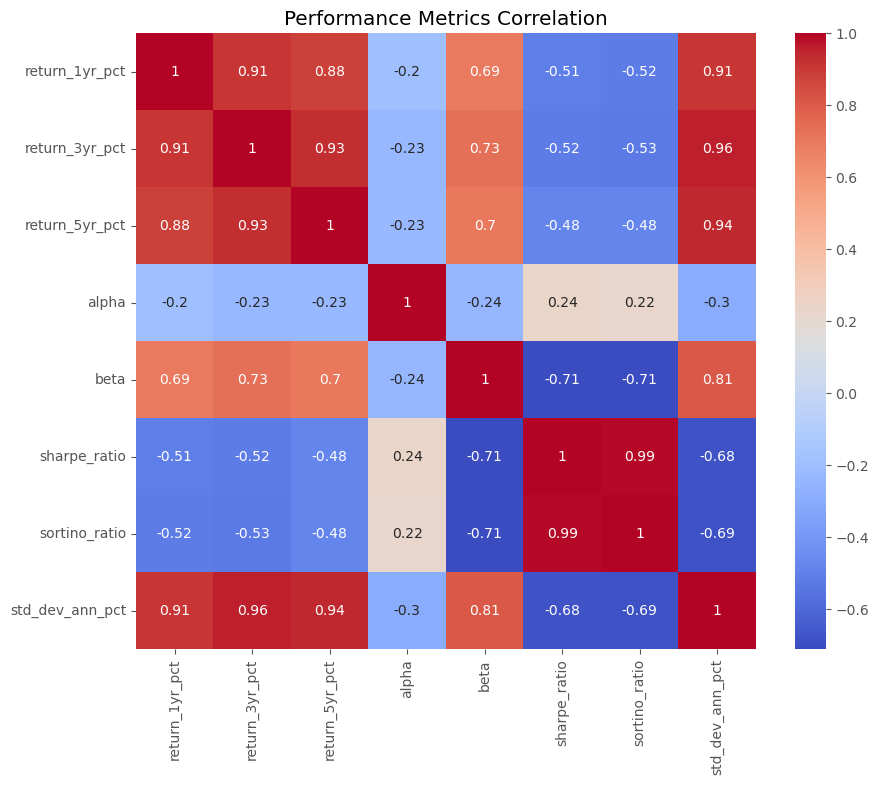

In [27]:
cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    performance[cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Performance Metrics Correlation")
plt.show()

# Key Findings

1. Top-performing funds achieved the highest 3-year returns.
2. High Sharpe Ratio funds delivered superior risk-adjusted performance.
3. Most funds have positive alpha values.
4. Higher beta funds generally exhibit higher volatility.
5. Risk and return show a positive relationship.
6. A few funds charge significantly higher expense ratios.
7. Large AUM funds dominate the market.
8. Some funds experienced substantial drawdowns.
9. Sharpe Ratio strongly correlates with returns.
10. Risk metrics provide valuable insight beyond raw returns.